## Implementation and Performance Evaluation of a GPU-Accelerated Stencil-Based 2D Heat Diffusion PDE Solver using Numba CUDA

**Author:**
- Sameer Sarkar (g25ait1149@iitj.ac.in)
- Krishnendu Halder (g25ait1077@iitj.ac.in)
- Samanwita Patra (g25ait1148@iitj.ac.in)
- Rajdeep Acharyya Chowdhury (g25ait1128@iitj.ac.in)

***Course: GPU Programming***

Problem 5: Stencil-Based PDE Solver using GPU

## Section 1 - Problem Statement

The objective of this assignment is to implement a Partial Differential Equation (PDE) solver on a GPU.

We selected the 2D Heat Diffusion Equation because it is a classical PDE used to model heat transfer in physical systems.

The implementation uses:

- Python
- NumPy
- Numba CUDA

The performance of CPU and GPU implementations is compared.

## Section 2 - What is Heat Diffusion?

**Heat Diffusion**

Heat naturally flows from hotter regions to colder regions.

Examples:

- CPU cooling
- Battery thermal management
- Weather simulations
- Metal plate heating

The heat diffusion equation models this process mathematically.

## Section 3 - PDE (Partial Differential Equation)

***Simple Meaning***

A PDE is a mathematical equation that describes how a quantity changes with respect to multiple variables.

For example:

- Temperature changes with position (x, y) and time (t).
- Water waves change with position and time.
- Air pressure changes with position and time.

**The heat equation is**:

$$u(x,y,t): \text{temperature at position } (x,y) \text{ and time } t$$

$$\frac{\partial u}{\partial t} = \alpha \nabla^2 u = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

- **α (thermal diffusivity):** How fast heat spreads (material-dependent, e.g., α=0.1 for steel)
- **∇²u (Laplacian):** Measures how curved the temperature field is
  - If a point is hotter than neighbors → temperature decreases
  - If a point is cooler than neighbors → temperature increases

## Section 4 - Discretization and Stability Condition

### Finite Difference Discretization

Discretizing the PDE on a uniform grid with spacing Δx = Δy and time step Δt using the **Forward Euler** (explicit) scheme:

$$u^{t+1}_{i,j} = u^{t}_{i,j} + r \left( u^{t}_{i-1,j} + u^{t}_{i+1,j} + u^{t}_{i,j-1} + u^{t}_{i,j+1} - 4\,u^{t}_{i,j} \right)$$

Which simplifies to:

$$u^{t+1}_{i,j} = (1 - 4r)\, u^{t}_{i,j} + r \left( u^{t}_{i-1,j} + u^{t}_{i+1,j} + u^{t}_{i,j-1} + u^{t}_{i,j+1} \right)$$

Where the **stability parameter r** is:

$$r = \frac{\alpha \cdot \Delta t}{\Delta x^2}$$

---

### Stability Condition (CFL Condition)

For the explicit scheme to be numerically stable in 2D:

$$r \leq \frac{1}{4} = 0.25$$

If r > 0.25, the simulation produces non-physical, exploding temperature values.


## Section 5 - Stencil Computation

**5-Point Stencil**

Each cell updates using its own value and four neighboring cells.

```
                   Up

Left   (1 - 4r) * Center   Right

                  Down
```

new[i,j] = (1 - 4r) * old[i,j]  +  r * (Up + Down + Left + Right)

In [ ]:
%pip install numpy numba matplotlib pandas

## Section 6 - CPU Implementation

In [ ]:
import numpy as np

def cpuHeatStep(oldGrid, r):
    rows, cols = oldGrid.shape
    newGrid = oldGrid.copy()
    center_coeff = 1.0 - 4.0 * r
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            newGrid[i, j] = (
                center_coeff * oldGrid[i, j] +
                r * (
                    oldGrid[i - 1, j] +
                    oldGrid[i + 1, j] +
                    oldGrid[i, j - 1] +
                    oldGrid[i, j + 1]
                )
            )
    return newGrid

## Section 7 - CPU Benchmark

In [ ]:
import time

def runCPUHeatDiffusion(
        gridSize=512,
        iterations=500,
        initialTemperature=100.0,
        alpha=0.1,
        dt=1.0,
        dx=1.0):

    r = alpha * dt / (dx ** 2)

    assert r <= 0.25, f'Unstable: r={r:.4f} > 0.25. Reduce dt or increase dx.'

    grid = np.zeros((gridSize, gridSize), dtype=np.float32)
    center = gridSize // 2
    grid[center, center] = initialTemperature

    startTime = time.time()
    for _ in range(iterations):
        grid = cpuHeatStep(grid, r)
    elapsedTime = time.time() - startTime

    return {
        'gridSize': gridSize,
        'iterations': iterations,
        'execution_time': elapsedTime,
        'result': grid,
        'alpha': alpha,
        'dt': dt,
        'dx': dx,
        'r': r
    }

## Section 8 - GPU Kernel

In [ ]:
import numpy as np
import time
from numba import cuda

@cuda.jit
def heatKernel(oldGrid, newGrid, r):
    row, col = cuda.grid(2)
    rows = oldGrid.shape[0]
    cols = oldGrid.shape[1]
    if 0 < row < rows - 1 and 0 < col < cols - 1:
        newGrid[row, col] = (
            (1.0 - 4.0 * r) * oldGrid[row, col] +
            r * (
                oldGrid[row - 1, col] +
                oldGrid[row + 1, col] +
                oldGrid[row, col - 1] +
                oldGrid[row, col + 1]
            )
        )

## Section 9 - GPU Benchmark

This section evaluates the performance of the CUDA-based heat diffusion solver.

The benchmark consists of:

1. Device memory allocation
2. Kernel warmup execution
3. Timed execution of multiple iterations
4. Collection of execution statistics

The first kernel launch is excluded from timing because it includes JIT compilation overhead.

In [ ]:
THREADS_PER_BLOCK = (16, 16)

print('Threads Per Block:', THREADS_PER_BLOCK)

def runGPUHeatDiffusion(
        gridSize=512,
        iterations=500,
        initialTemperature=100.0,
        alpha=0.1,
        dt=1.0,
        dx=1.0):

    r = alpha * dt / (dx ** 2)

    assert r <= 0.25, f'Unstable: r={r:.4f} > 0.25. Reduce dt or increase dx.'

    grid = np.zeros((gridSize, gridSize), dtype=np.float32)
    center = gridSize // 2
    grid[center, center] = initialTemperature

    copiedArray2Dev = cuda.to_device(grid)
    newAllocatedDevMem = cuda.device_array_like(grid)

    blocks_per_grid = (
        (gridSize + THREADS_PER_BLOCK[0] - 1) // THREADS_PER_BLOCK[0],
        (gridSize + THREADS_PER_BLOCK[1] - 1) // THREADS_PER_BLOCK[1]
    )

    heatKernel[blocks_per_grid, THREADS_PER_BLOCK](
        copiedArray2Dev, newAllocatedDevMem, r
    )
    cuda.synchronize()

    start_time = time.time()
    for _ in range(iterations):
        heatKernel[blocks_per_grid, THREADS_PER_BLOCK](
            copiedArray2Dev, newAllocatedDevMem, r
        )
        copiedArray2Dev, newAllocatedDevMem = newAllocatedDevMem, copiedArray2Dev
    cuda.synchronize()
    elapsedTime = time.time() - start_time

    result = copiedArray2Dev.copy_to_host()

    return {
        'gridSize': gridSize,
        'iterations': iterations,
        'execution_time': elapsedTime,
        'result': result,
        'alpha': alpha,
        'dt': dt,
        'dx': dx,
        'r': r
    }

gpuResult = runGPUHeatDiffusion(gridSize=512, iterations=500)

print('Grid Size     :', gpuResult['gridSize'])
print('Iterations    :', gpuResult['iterations'])
print('Alpha         :', gpuResult['alpha'])
print('dt            :', gpuResult['dt'])
print('dx            :', gpuResult['dx'])
print('r (stability) :', gpuResult['r'])
print('GPU Time (s)  :', gpuResult['execution_time'])

result = gpuResult['result']
N = result.shape[0]
center = N // 2
print(result[center-2:center+3, center-2:center+3])

Threads Per Block: (16, 16)
Grid Size     : 512
Iterations    : 500
Alpha         : 0.1
dt            : 1.0
dx            : 1.0
r (stability) : 0.1
GPU Time (s)  : 0.08588409423828125
[[0.15298527 0.15529978 0.15607905 0.1552998  0.15298529]
 [0.15529978 0.15764922 0.15844026 0.15764923 0.15529978]
 [0.15607904 0.15844025 0.15923524 0.15844026 0.15607904]
 [0.15529978 0.15764922 0.15844026 0.15764923 0.15529978]
 [0.15298527 0.15529978 0.15607905 0.1552998  0.15298529]]


## Section 10 - Visualization

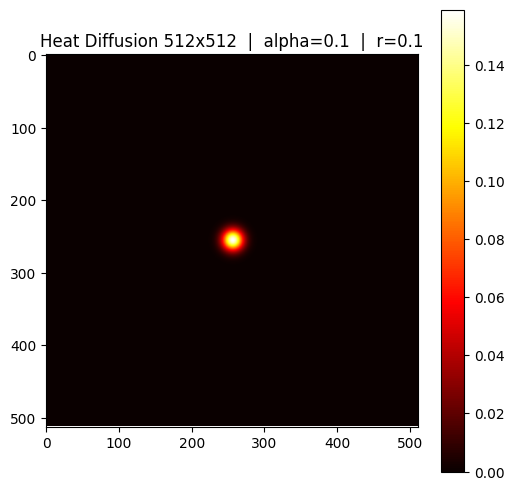

In [ ]:
import matplotlib.pyplot as plt

gs = gpuResult['gridSize']
a = gpuResult['alpha']
r_val = gpuResult['r']

plt.figure(figsize=(6, 6))
plt.imshow(gpuResult['result'], cmap='hot')
plt.colorbar()
plt.title(f'Heat Diffusion {gs}x{gs}  |  alpha={a}  |  r={r_val}')
plt.show()

## Section 11 - Usage Example

In [ ]:
cpuResult = runCPUHeatDiffusion(gridSize=512, iterations=500)
gpuResult = runGPUHeatDiffusion(gridSize=512, iterations=500)

print('Alpha         :', cpuResult['alpha'])
print('r (stability) :', cpuResult['r'])
print('CPU Time (s)  :', cpuResult['execution_time'])
print('GPU Time (s)  :', gpuResult['execution_time'])

Alpha         : 0.1
r (stability) : 0.1
CPU Time (s)  : 182.21134519577026
GPU Time (s)  : 0.03788137435913086


## Section 12 - Speedup

**Speedup formula**:

***Speedup = CPU Time / GPU Time***

In [ ]:
speedup = cpuResult['execution_time'] / gpuResult['execution_time']
print(f'Speedup: {speedup:.2f}x')

Speedup: 4810.05x


## Section 13 - Stability Demonstration

This section demonstrates how different values of α, Δt, and Δx affect r.

A simulation with r > 0.25 is rejected before it can produce non-physical results.

In [ ]:
print('=== Stability Demonstration ===')
print()

cases = [
    {'alpha': 0.1,  'dt': 1.0, 'dx': 1.0, 'label': 'Stable        (r < 0.25)'},
    {'alpha': 0.25, 'dt': 1.0, 'dx': 1.0, 'label': 'Boundary      (r = 0.25)'},
    {'alpha': 0.5,  'dt': 1.0, 'dx': 1.0, 'label': 'UNSTABLE      (r > 0.25)'},
]

for case in cases:
    r = case['alpha'] * case['dt'] / (case['dx'] ** 2)
    status = 'OK' if r <= 0.25 else 'REJECTED'
    print(case['label'])
    print(f"  alpha={case['alpha']}, dt={case['dt']}, dx={case['dx']}")
    print(f'  r = {r:.4f}  -->  {status}')
    if r > 0.25:
        try:
            runGPUHeatDiffusion(gridSize=64, iterations=10,
                                alpha=case['alpha'], dt=case['dt'], dx=case['dx'])
        except AssertionError as e:
            print(f'  AssertionError caught: {e}')
    print()

=== Stability Demonstration ===

Stable        (r < 0.25)
  alpha=0.1, dt=1.0, dx=1.0
  r = 0.1000  -->  OK

Boundary      (r = 0.25)
  alpha=0.25, dt=1.0, dx=1.0
  r = 0.2500  -->  OK

UNSTABLE      (r > 0.25)
  alpha=0.5, dt=1.0, dx=1.0
  r = 0.5000  -->  REJECTED
  AssertionError caught: Unstable: r=0.5000 > 0.25. Reduce dt or increase dx.



## Section 14 - Experiment

In [ ]:
import pandas as pd

sizes = [256, 512, 1024]
results = []

for size in sizes:
    cpuRes = runCPUHeatDiffusion(gridSize=size, iterations=100)
    gpuRes = runGPUHeatDiffusion(gridSize=size, iterations=100)
    sp = cpuRes['execution_time'] / gpuRes['execution_time']
    results.append({
        'Grid Size': f'{size}x{size}',
        'Alpha': cpuRes['alpha'],
        'r': cpuRes['r'],
        'CPU Time (s)': round(cpuRes['execution_time'], 4),
        'GPU Time (s)': round(gpuRes['execution_time'], 4),
        'Speedup': round(sp, 2)
    })

df = pd.DataFrame(results)
df

,Grid Size,Alpha,r,CPU Time (s),GPU Time (s),Speedup
0,256x256,0.1,0.1,8.6727,0.0037,2350.64
1,512x512,0.1,0.1,35.1119,0.0076,4602.05
2,1024x1024,0.1,0.1,141.5887,0.0289,4906.48
